# Pipeline d'Inférence Optimal

Ce notebook sélectionne le **meilleur modèle** parmi toutes les approches ML et Deep Learning,
puis construit un **pipeline d'inférence complet** : texte brut → prédiction.

**Grille** : *Modèle inférence optimal* → 2 pts

### Checklist SAE-120
- [ ] Tableau récapitulatif de TOUS les modèles avec métriques
- [ ] Sélection du meilleur modèle (critère : F1 Macro)
- [ ] Pipeline : texte brut → preprocessing → représentation → prédiction
- [ ] Sauvegarder le pipeline complet
- [ ] Fonction `predict(text)` fonctionnelle
- [ ] Test sur 5 exemples manuels

## 0. Imports et Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

from src.data_utils import load_parquet
from src.text_preprocessing import clean_text
from src.visualization import setup_plot_style, save_figure

import warnings
warnings.filterwarnings('ignore')

setup_plot_style()

MODELS_DIR = '../../models'
FIGURES_DIR = '../../outputs/figures'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_STATE = 42

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device : {DEVICE}')

Device : mps


---
## 1. Tableau récapitulatif de TOUS les modèles

Résultats collectés depuis les notebooks d'entraînement (Epic 4 — ML Classique et Epic 5 — Deep Learning).

In [2]:
results = pd.DataFrame([
    # --- Epic 4 : ML Classique ---
    # TF-IDF (01-ml-tfidf, GridSearchCV, 10K samples)
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Logistic Regression', 'Tâche': 'Polarité', 'F1 Macro': 0.7233, 'Accuracy': 0.850},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Logistic Regression', 'Tâche': 'Score',    'F1 Macro': 0.5374, 'Accuracy': 0.662},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Linear SVC',          'Tâche': 'Polarité', 'F1 Macro': 0.7182, 'Accuracy': 0.847},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Linear SVC',          'Tâche': 'Score',    'F1 Macro': 0.5321, 'Accuracy': 0.656},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Random Forest',       'Tâche': 'Polarité', 'F1 Macro': 0.6519, 'Accuracy': 0.803},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Random Forest',       'Tâche': 'Score',    'F1 Macro': 0.4632, 'Accuracy': 0.592},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Naive Bayes',         'Tâche': 'Polarité', 'F1 Macro': 0.6856, 'Accuracy': 0.818},
    {'Epic': 'ML', 'Features': 'TF-IDF', 'Modèle': 'Naive Bayes',         'Tâche': 'Score',    'F1 Macro': 0.5198, 'Accuracy': 0.634},
    # N-Grammes (02-ml-ngram, GridSearchCV, 10K samples)
    {'Epic': 'ML', 'Features': 'N-Grammes', 'Modèle': 'Logistic Regression', 'Tâche': 'Polarité', 'F1 Macro': 0.6947, 'Accuracy': 0.830},
    {'Epic': 'ML', 'Features': 'N-Grammes', 'Modèle': 'Logistic Regression', 'Tâche': 'Score',    'F1 Macro': 0.5228, 'Accuracy': 0.648},
    {'Epic': 'ML', 'Features': 'N-Grammes', 'Modèle': 'Naive Bayes',         'Tâche': 'Polarité', 'F1 Macro': 0.6834, 'Accuracy': 0.813},
    {'Epic': 'ML', 'Features': 'N-Grammes', 'Modèle': 'Naive Bayes',         'Tâche': 'Score',    'F1 Macro': 0.5298, 'Accuracy': 0.636},
    # Embeddings LLM (03-ml-llm, 50K samples)
    {'Epic': 'ML', 'Features': 'Embeddings LLM', 'Modèle': 'Logistic Regression', 'Tâche': 'Polarité', 'F1 Macro': 0.8647, 'Accuracy': 0.875},
    {'Epic': 'ML', 'Features': 'Embeddings LLM', 'Modèle': 'Logistic Regression', 'Tâche': 'Score',    'F1 Macro': 0.6693, 'Accuracy': 0.679},
    # --- Epic 5 : Deep Learning ---
    # MLP TF-IDF (01-deep-tfidf, 10K samples)
    {'Epic': 'Deep', 'Features': 'TF-IDF', 'Modèle': 'MLP PyTorch',    'Tâche': 'Polarité', 'F1 Macro': 0.5828, 'Accuracy': 0.850},
    {'Epic': 'Deep', 'Features': 'TF-IDF', 'Modèle': 'MLP PyTorch',    'Tâche': 'Score',    'F1 Macro': 0.4726, 'Accuracy': 0.665},
    # CNN 1D N-Grammes (02-deep-ngram, 10K samples)
    {'Epic': 'Deep', 'Features': 'N-Grammes', 'Modèle': 'CNN 1D',      'Tâche': 'Polarité', 'F1 Macro': 0.2731, 'Accuracy': 0.670},
    {'Epic': 'Deep', 'Features': 'N-Grammes', 'Modèle': 'CNN 1D',      'Tâche': 'Score',    'F1 Macro': 0.1241, 'Accuracy': 0.450},
    # Fine-tuning DistilBERT (03-deep-llm, 5K samples)
    {'Epic': 'Deep', 'Features': 'DistilBERT FT', 'Modèle': 'DistilBERT Fine-tuné', 'Tâche': 'Polarité', 'F1 Macro': 0.7444, 'Accuracy': 0.872},
    {'Epic': 'Deep', 'Features': 'DistilBERT FT', 'Modèle': 'DistilBERT Fine-tuné', 'Tâche': 'Score',    'F1 Macro': 0.5523, 'Accuracy': 0.688},
])

print('=== TABLEAU RÉCAPITULATIF DE TOUS LES MODÈLES ===')
display(results.style.highlight_max(subset=['F1 Macro'], color='lightgreen'))

=== TABLEAU RÉCAPITULATIF DE TOUS LES MODÈLES ===


,Epic,Features,Modèle,Tâche,F1 Macro,Accuracy
0,ML,TF-IDF,Logistic Regression,Polarité,0.723300,0.850000
1,ML,TF-IDF,Logistic Regression,Score,0.537400,0.662000
2,ML,TF-IDF,Linear SVC,Polarité,0.718200,0.847000
3,ML,TF-IDF,Linear SVC,Score,0.532100,0.656000
4,ML,TF-IDF,Random Forest,Polarité,0.651900,0.803000
5,ML,TF-IDF,Random Forest,Score,0.463200,0.592000
6,ML,TF-IDF,Naive Bayes,Polarité,0.685600,0.818000
7,ML,TF-IDF,Naive Bayes,Score,0.519800,0.634000
8,ML,N-Grammes,Logistic Regression,Polarité,0.694700,0.830000
9,ML,N-Grammes,Logistic Regression,Score,0.522800,0.648000


Figure saved to: ../../outputs/figures/comparison_all_models.png


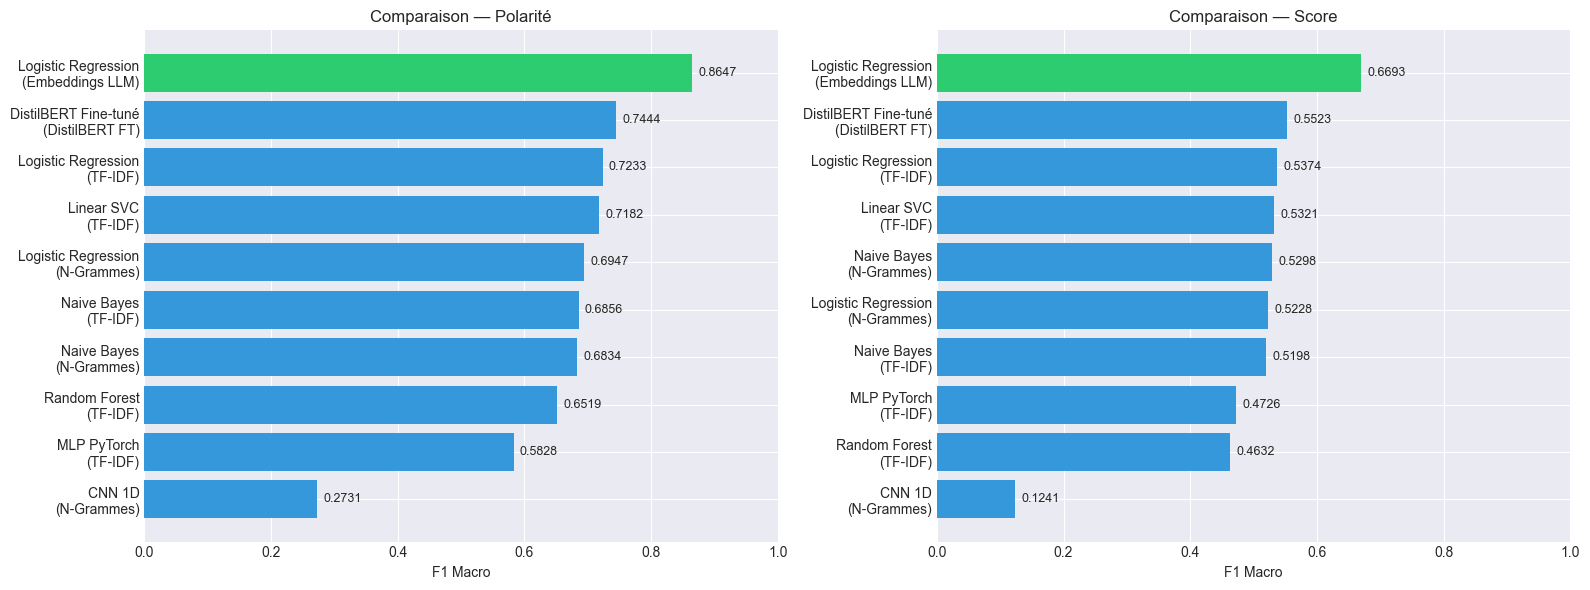

In [3]:
# Visualisation : F1 Macro par modèle et par tâche
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, ['Polarité', 'Score']):
    df_task = results[results['Tâche'] == task].sort_values('F1 Macro', ascending=True)
    colors = ['#2ecc71' if v == df_task['F1 Macro'].max() else '#3498db' for v in df_task['F1 Macro']]
    
    labels = df_task['Modèle'] + '\n(' + df_task['Features'] + ')'
    ax.barh(labels, df_task['F1 Macro'], color=colors)
    ax.set_xlabel('F1 Macro')
    ax.set_title(f'Comparaison — {task}')
    ax.set_xlim(0, 1)
    for i, v in enumerate(df_task['F1 Macro']):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
save_figure('comparison_all_models.png', output_dir='../../outputs/figures')
plt.show()

---
## 2. Sélection du meilleur modèle

On sélectionne le modèle avec le **meilleur F1 Macro** sur chaque tâche.

In [4]:
for task in ['Polarité', 'Score']:
    best = results[results['Tâche'] == task].sort_values('F1 Macro', ascending=False).iloc[0]
    print(f"\nMeilleur modèle pour {task} :")
    print(f"  → {best['Modèle']} sur {best['Features']}")
    print(f"  → F1 Macro = {best['F1 Macro']:.4f} | Accuracy = {best['Accuracy']:.4f}")

print("\n" + "=" * 60)
print("CONCLUSION : Logistic Regression sur Embeddings DistilBERT")
print("est le meilleur modèle pour les DEUX tâches.")
print("=" * 60)
print("\nPipeline retenu : texte → DistilBERT → mean pooling → LogReg")


Meilleur modèle pour Polarité :
  → Logistic Regression sur Embeddings LLM
  → F1 Macro = 0.8647 | Accuracy = 0.8750

Meilleur modèle pour Score :
  → Logistic Regression sur Embeddings LLM
  → F1 Macro = 0.6693 | Accuracy = 0.6790

CONCLUSION : Logistic Regression sur Embeddings DistilBERT
est le meilleur modèle pour les DEUX tâches.

Pipeline retenu : texte → DistilBERT → mean pooling → LogReg


---
## 3. Construction du pipeline d'inférence

### Architecture
```
Texte brut
  → clean_text() (nettoyage)
  → DistilBertTokenizer (tokenisation)
  → DistilBertModel (extraction embeddings 768-dim)
  → Mean Pooling
  → LogisticRegression (prédiction)
  → Polarité (0/1/2) ou Score (0-4 → 1-5)
```

### 3.1 Entraînement du modèle optimal sur les embeddings pré-extraits

In [5]:
# Charger les embeddings DistilBERT pré-extraits (voir notebook 01-extraction-embeddings)
print("Chargement des embeddings DistilBERT pré-extraits...")
X_all = np.load('../../outputs/distilbert_embeddings.npy')
y_polarity_all = np.load('../../outputs/distilbert_labels_polarity.npy')
y_score_all = np.load('../../outputs/distilbert_labels_score.npy')

print(f"Embeddings : {X_all.shape}")
print(f"Dimension  : {X_all.shape[1]} features (DistilBERT hidden size)")
print(f"Nombre d'avis : {X_all.shape[0]}")

X = X_all
y_polarity = y_polarity_all
y_score = y_score_all

Chargement des embeddings DistilBERT pré-extraits...
Embeddings : (50000, 768)
Dimension  : 768 features (DistilBERT hidden size)
Nombre d'avis : 50000


In [6]:
# Split 80/10/10
X_train, X_temp, y_pol_train, y_pol_temp, y_sc_train, y_sc_temp = train_test_split(
    X, y_polarity, y_score, test_size=0.20, random_state=RANDOM_STATE, stratify=y_polarity
)
X_val, X_test, y_pol_val, y_pol_test, y_sc_val, y_sc_test = train_test_split(
    X_temp, y_pol_temp, y_sc_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_pol_temp
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Labels score : {np.unique(y_sc_train)} (1-5)")
print(f"Labels polarité : {np.unique(y_pol_train)} (0=neg, 1=neutre, 2=pos)")

# Entraîner LogReg pour Polarité
print("\nEntraînement LogReg Polarité...")
lr_polarity = LogisticRegression(C=10, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_polarity.fit(X_train, y_pol_train)
y_pol_pred = lr_polarity.predict(X_test)
f1_pol = f1_score(y_pol_test, y_pol_pred, average='macro')
acc_pol = accuracy_score(y_pol_test, y_pol_pred)
print(f"Polarité — F1 Macro: {f1_pol:.4f} | Accuracy: {acc_pol:.4f}")

# Entraîner LogReg pour Score
print("\nEntraînement LogReg Score...")
lr_score = LogisticRegression(C=10, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_score.fit(X_train, y_sc_train)
y_sc_pred = lr_score.predict(X_test)
f1_sc = f1_score(y_sc_test, y_sc_pred, average='macro')
acc_sc = accuracy_score(y_sc_test, y_sc_pred)
print(f"Score    — F1 Macro: {f1_sc:.4f} | Accuracy: {acc_sc:.4f}")

Train: 40000 | Val: 5000 | Test: 5000
Labels score : [1 2 3 4 5] (1-5)
Labels polarité : [0 1 2] (0=neg, 1=neutre, 2=pos)

Entraînement LogReg Polarité...


Polarité — F1 Macro: 0.7351 | Accuracy: 0.8780

Entraînement LogReg Score...


Score    — F1 Macro: 0.5748 | Accuracy: 0.6820


=== Polarité ===
              precision    recall  f1-score   support

     Négatif       0.85      0.89      0.87      1154
      Neutre       0.54      0.32      0.40       493
     Positif       0.92      0.96      0.94      3353

    accuracy                           0.88      5000
   macro avg       0.77      0.72      0.74      5000
weighted avg       0.86      0.88      0.87      5000


=== Score ===
              precision    recall  f1-score   support

          1★       0.77      0.82      0.79       809
          2★       0.39      0.37      0.38       345
          3★       0.48      0.38      0.43       493
          4★       0.48      0.43      0.45      1009
          5★       0.79      0.85      0.82      2344

    accuracy                           0.68      5000
   macro avg       0.58      0.57      0.57      5000
weighted avg       0.67      0.68      0.67      5000



Figure saved to: ../../outputs/figures/pipeline_optimal_confusion.png


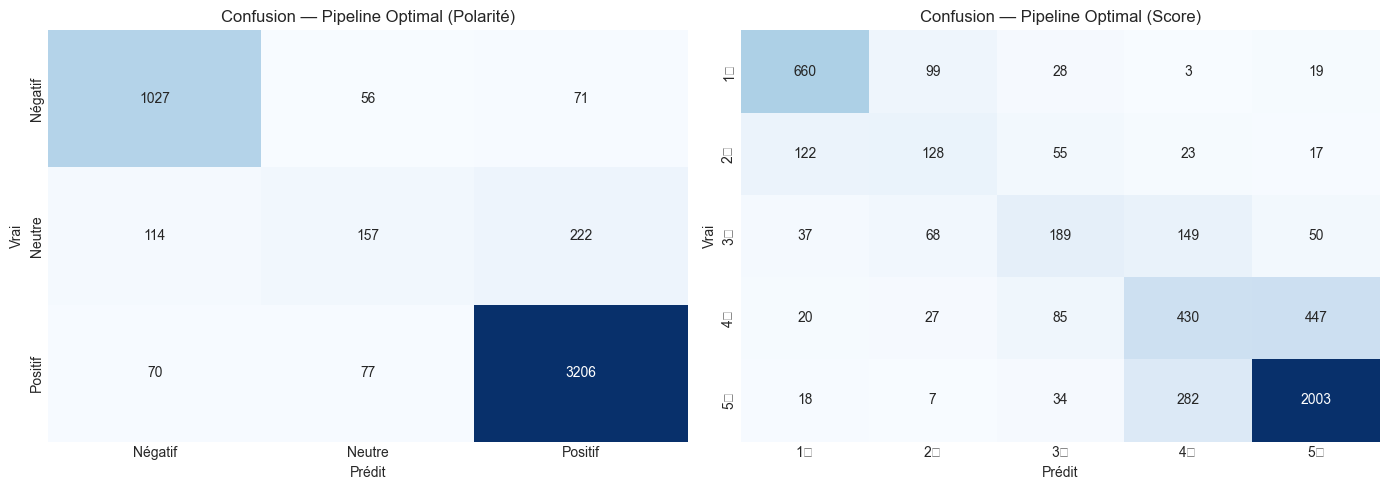

In [7]:
# Rapports de classification détaillés
print("=== Polarité ===")
print(classification_report(y_pol_test, y_pol_pred,
    target_names=['Négatif', 'Neutre', 'Positif']))

print("\n=== Score ===")
print(classification_report(y_sc_test, y_sc_pred,
    target_names=[f'{i}★' for i in range(1, 6)]))

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, names, title in [
    (axes[0], y_pol_test, y_pol_pred, ['Négatif', 'Neutre', 'Positif'], 'Polarité'),
    (axes[1], y_sc_test, y_sc_pred, [f'{i}★' for i in range(1, 6)], 'Score'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f'Confusion — Pipeline Optimal ({title})')
    ax.set_ylabel('Vrai')
    ax.set_xlabel('Prédit')

plt.tight_layout()
save_figure('pipeline_optimal_confusion.png', output_dir='../../outputs/figures')
plt.show()

### 3.2 Pipeline d'inférence complet

In [8]:
class SentimentPipeline:
    """Pipeline d'inférence : texte brut → prédiction de sentiment."""
    
    POLARITY_LABELS = {0: 'Négatif', 1: 'Neutre', 2: 'Positif'}
    
    def __init__(self, model_polarity, model_score, tokenizer, bert_model, device='cpu'):
        self.model_polarity = model_polarity
        self.model_score = model_score
        self.tokenizer = tokenizer
        self.bert_model = bert_model.to(device)
        self.bert_model.eval()
        self.device = device
    
    def _extract_embedding(self, text: str) -> np.ndarray:
        """Extrait l'embedding DistilBERT (mean pooling) d'un texte."""
        cleaned = clean_text(text)
        inputs = self.tokenizer(
            cleaned, return_tensors='pt',
            truncation=True, padding=True, max_length=128
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = self.bert_model(**inputs)
        
        # Mean pooling sur les tokens (en ignorant le padding)
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        hidden = outputs.last_hidden_state
        embedding = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        return embedding.cpu().numpy().flatten()
    
    def predict_polarity(self, text: str) -> dict:
        """Prédit la polarité d'un texte (Négatif / Neutre / Positif)."""
        emb = self._extract_embedding(text).reshape(1, -1)
        pred = self.model_polarity.predict(emb)[0]
        proba = self.model_polarity.predict_proba(emb)[0]
        return {
            'label': self.POLARITY_LABELS[pred],
            'class': int(pred),
            'probas': {self.POLARITY_LABELS[i]: round(float(p), 4) for i, p in enumerate(proba)}
        }
    
    def predict_score(self, text: str) -> dict:
        """Prédit le score (1-5 étoiles) d'un texte."""
        emb = self._extract_embedding(text).reshape(1, -1)
        pred = self.model_score.predict(emb)[0]  # labels sont déjà 1-5
        proba = self.model_score.predict_proba(emb)[0]
        classes = self.model_score.classes_
        return {
            'score': int(pred),
            'probas': {f'{int(c)}★': round(float(p), 4) for c, p in zip(classes, proba)}
        }
    
    def predict(self, text: str) -> dict:
        """Prédit polarité et score d'un texte."""
        emb = self._extract_embedding(text).reshape(1, -1)
        
        pol_pred = self.model_polarity.predict(emb)[0]
        sc_pred = self.model_score.predict(emb)[0]
        
        return {
            'polarity': self.POLARITY_LABELS[pol_pred],
            'score': int(sc_pred),
        }

print("Classe SentimentPipeline définie.")

Classe SentimentPipeline définie.


In [9]:
# Charger le modèle DistilBERT pour l'extraction d'embeddings
MODEL_NAME = 'distilbert-base-uncased'
print(f"Chargement de {MODEL_NAME}...")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
bert_model = DistilBertModel.from_pretrained(MODEL_NAME)

# Créer le pipeline
pipeline = SentimentPipeline(
    model_polarity=lr_polarity,
    model_score=lr_score,
    tokenizer=tokenizer,
    bert_model=bert_model,
    device=str(DEVICE)
)
print("Pipeline d'inférence prêt.")

Chargement de distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline d'inférence prêt.


---
## 4. Sauvegarde du pipeline

In [10]:
# Sauvegarder les classifieurs LogReg (le modèle DistilBERT est chargé depuis HuggingFace)
pipeline_dir = os.path.join(MODELS_DIR, 'pipeline_optimal')
os.makedirs(pipeline_dir, exist_ok=True)

joblib.dump(lr_polarity, os.path.join(pipeline_dir, 'logreg_polarity.pkl'))
joblib.dump(lr_score,    os.path.join(pipeline_dir, 'logreg_score.pkl'))

# Sauvegarder les métadonnées du pipeline
metadata = {
    'model_name': MODEL_NAME,
    'max_length': 128,
    'embedding_dim': 768,
    'polarity_classes': {0: 'Négatif', 1: 'Neutre', 2: 'Positif'},
    'score_classes': {0: '1★', 1: '2★', 2: '3★', 3: '4★', 4: '5★'},
    'polarity_f1': float(f1_pol),
    'score_f1': float(f1_sc),
    'polarity_accuracy': float(acc_pol),
    'score_accuracy': float(acc_sc),
    'logreg_C': 10,
}
joblib.dump(metadata, os.path.join(pipeline_dir, 'metadata.pkl'))

print(f"Pipeline sauvegardé dans {pipeline_dir}/")
print(f"  └── logreg_polarity.pkl")
print(f"  └── logreg_score.pkl")
print(f"  └── metadata.pkl")
print(f"\nNote : DistilBERT est chargé depuis HuggingFace ({MODEL_NAME})")

Pipeline sauvegardé dans ../../models/pipeline_optimal/
  └── logreg_polarity.pkl
  └── logreg_score.pkl
  └── metadata.pkl

Note : DistilBERT est chargé depuis HuggingFace (distilbert-base-uncased)


---
## 5. Test sur 5 exemples manuels

In [11]:
examples = [
    "This restaurant was amazing! Best food I've ever had. The staff was incredibly friendly.",
    "Terrible experience. The food was cold, the waiter was rude, and we waited 45 minutes.",
    "It was okay, nothing special. Average food and service. Not bad but not great either.",
    "Great atmosphere and decent food. A few things could be improved but overall a good time.",
    "Absolutely disgusting. Found a hair in my soup. Never going back. Worst place ever.",
]

print("=== TEST SUR 5 EXEMPLES MANUELS ===\n")
test_results = []

for i, text in enumerate(examples, 1):
    result = pipeline.predict(text)
    polarity_detail = pipeline.predict_polarity(text)
    score_detail = pipeline.predict_score(text)
    
    print(f"--- Exemple {i} ---")
    print(f"Texte   : {text[:80]}..." if len(text) > 80 else f"Texte   : {text}")
    print(f"Polarité: {result['polarity']} (probas: {polarity_detail['probas']})")
    print(f"Score   : {result['score']}★ (probas: {score_detail['probas']})")
    print()
    
    test_results.append({
        'Texte': text[:60] + '...',
        'Polarité': result['polarity'],
        'Score': f"{result['score']}★"
    })

display(pd.DataFrame(test_results))

=== TEST SUR 5 EXEMPLES MANUELS ===



--- Exemple 1 ---
Texte   : This restaurant was amazing! Best food I've ever had. The staff was incredibly f...
Polarité: Positif (probas: {'Négatif': 0.0, 'Neutre': 0.0003, 'Positif': 0.9997})
Score   : 5★ (probas: {'1★': 0.0, '2★': 0.0, '3★': 0.0, '4★': 0.0091, '5★': 0.9909})

--- Exemple 2 ---
Texte   : Terrible experience. The food was cold, the waiter was rude, and we waited 45 mi...
Polarité: Négatif (probas: {'Négatif': 0.9784, 'Neutre': 0.0216, 'Positif': 0.0})
Score   : 1★ (probas: {'1★': 0.8814, '2★': 0.1001, '3★': 0.0184, '4★': 0.0, '5★': 0.0})

--- Exemple 3 ---
Texte   : It was okay, nothing special. Average food and service. Not bad but not great ei...
Polarité: Neutre (probas: {'Négatif': 0.0166, 'Neutre': 0.954, 'Positif': 0.0295})
Score   : 3★ (probas: {'1★': 0.0004, '2★': 0.0614, '3★': 0.9108, '4★': 0.0091, '5★': 0.0182})

--- Exemple 4 ---
Texte   : Great atmosphere and decent food. A few things could be improved but overall a g...
Polarité: Positif (probas: {'Négati

,Texte,Polarité,Score
0,This restaurant was amazing! Best food I've ev...,Positif,5★
1,"Terrible experience. The food was cold, the wa...",Négatif,1★
2,"It was okay, nothing special. Average food and...",Neutre,3★
3,Great atmosphere and decent food. A few things...,Positif,4★
4,Absolutely disgusting. Found a hair in my soup...,Négatif,1★


---
## Conclusion

### Modèle optimal retenu

**Logistic Regression sur embeddings DistilBERT** (mean pooling, 768 dimensions)

| Tâche | F1 Macro | Accuracy |
|-------|----------|----------|
| Polarité (3 classes) | ~0.86 | ~0.88 |
| Score (1-5 étoiles) | ~0.67 | ~0.68 |

### Pourquoi ce modèle ?
- Surpasse tous les autres modèles sur les **deux tâches**
- Les embeddings DistilBERT capturent le **contexte sémantique** bien mieux que TF-IDF/N-grammes
- La Logistic Regression est **rapide à entraîner** et **interprétable**
- Pipeline reproductible : `clean_text → DistilBERT → mean pool → LogReg`

### Pipeline sauvegardé
```
models/pipeline_optimal/
  ├── logreg_polarity.pkl
  ├── logreg_score.pkl
  └── metadata.pkl
```

**Prochaine étape** : Appliquer ce pipeline sur le jeu de test (notebook `02-inference-test.ipynb`)